# Fitting with ChiSquare, Binned Likelihood, and Unbinned Likelihood

This is an introduction to likelihood fits, both binned and unbinned, trying to show the following points:
1. How likelihood fits work, both binned and unbinned.
2. When to use which type of fits, also including ChiSquare.
3. See how the amount of statistics influences the above choice.

Comparisons are naturally done with the ChiSquare. Also, this program serves as an introduction to fitting with iMinuit.

The exercise is made to play around with the (statistics of) the signal and background distributions, so that you can get a feel for the advantages and drawbacks of each method... and make sure that you feel comfortable in applying all three.

### References:
- Barlow: 5.3 + 5.4 + 5.6
- Bevington: Chapter 10

### Authors: 
- Troels C. Petersen (Niels Bohr Institute)

### Date:    
- 21-11-2024 (latest update)

***

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats

Below are some of the general program settings, which are good to have in one place:

In [32]:
r = np.random        # Random generator
r.seed(42)           # Set a random seed (but a fixed one)

save_plots = False   # For now, don't save plots (once you trust your code, switch on)
verbose = True       # For now, print a lot of output (once you trust your code, switch off)
Nverbose = 10        # But only print a lot for the first 10 random numbers

## Truth values used:

We choose some *given* values (the "truth") to simulate the data with. The goal of the fits is to estimate these values most accurately, as if you had data, and wanted to extract these values from it.

In [33]:
# Signal parameters:
Npeak = 2000           # Number of random Gaussian points
mu_peak = 3.0        # Peak location
sigma_peak = 0.3     # Peak width

# Background parameters:
Nbkg  = 5000           # Number of random Exponential points
tau_bkg = 3.0        # Decay constant (could be anything!)

## Create the data:

We create some data with a signal peak on an exponential background:

In [34]:
# Create signal:
x_peak = r.normal(loc=mu_peak, scale=sigma_peak, size=Npeak)

# Create background:
x_bkg  = r.exponential(tau_bkg, Nbkg)

# Combine the two:
x_all = np.concatenate((x_peak, x_bkg), axis=0)
if (verbose) :
    print(x_all)

[3.14901425 2.95852071 3.19430656 ... 0.14342912 4.53600383 0.87340812]


## Histogram of data:

Since we are considering both ChiSquare (chi2) and Binned Likelihood (bllh), we start with the histogram, which is the input for both of these. Of course, the Unbinned Likelihood (ullh) doesn't care about binning!

### Note on binning:
It is very important to specify - in a well thought manner - the range and binning to use. Many problems could have been avoided by a few minutes (or even seconds!) of consideration from the beginning. 

In [35]:
# General input:
Nbins = 100
xmin, xmax = 0, 10
binwidth = (xmax-xmin)/Nbins

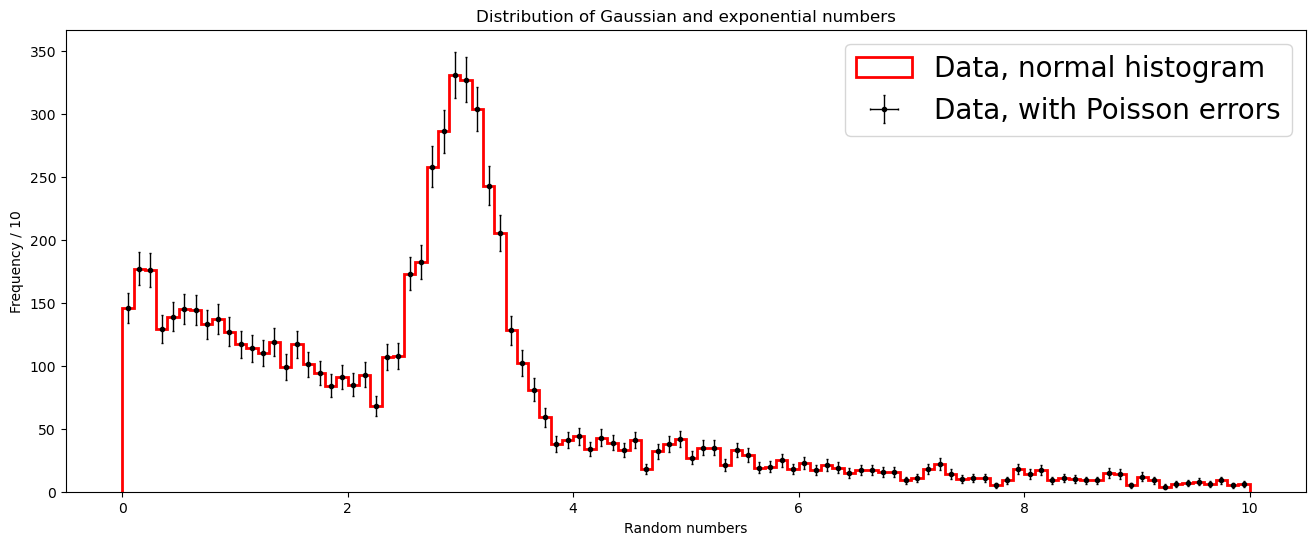

In [36]:
# Create just a single figure and axes, and a (classic) histogram:
fig, ax = plt.subplots(figsize=(16, 6))
hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='red', label='Data, normal histogram')

# Find the x, y and error on y (sy) given the histogram:
counts, bin_edges = np.histogram(x_all, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts
sy = np.sqrt(counts)   # NOTE: We (naturally) assume that the bin count is Poisson distributed.
                       # This is an approximation, since there is a low count in the last bins.

# Now create a histogram with uncertainties (better, I would argue):
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

# Set the figure texts; xlabel, ylabel and title.
ax.set(xlabel="Random numbers",           # the label of the y axis
       ylabel="Frequency / 10",           # the label of the y axis
       title ="Distribution of Gaussian and exponential numbers")    # the title of the plot
ax.legend(loc='best', fontsize=20);       # could also be # loc = 'upper right' e.g.

## Fit to the data / histogram (1D):

Having created the data, we now want to fit the distributions in three ways:
1. ChiSquare fit
2. Binned Likelihood fit
3. Unbinned Likelihood fit

We first define the function to be fitted with, a Gaussian and and Exponential PDF in this case:

In [37]:
# Define background PDF:
def exp_pdf(x, tau):
    """Exponential with lifetime tau"""
    return 1.0 / tau * np.exp(-x/tau)

In [38]:
# Define signal PDF:
def gauss_pdf(x, mu, sigma) :
    """Gaussian"""
    return 1.0 / np.sqrt(2*np.pi) / sigma * np.exp( -0.5 * (x-mu)**2 / sigma**2)

In [39]:
# Define your actual fitting function, with both background and signal in:
# which is NOT normalised but has normalisation constants "N" in, and includes the bin width:
def fit_pdf(x, Nexp, tau, Ngauss, mu, sigma) :
    """Exponential + Gaussian"""
    return Nexp * binwidth * exp_pdf(x, tau) + Ngauss * binwidth * gauss_pdf(x, mu, sigma)

In [40]:
# Define your actual fitting function, with both background and signal in,
# which is NOT normalised but has normalisation constants "N" in, but does NOT includes the bin width:
def fit_pdf_llhfit(x, Nexp, tau, Ngauss, mu, sigma) :
    """Exponential + Gaussian"""
    return Nexp + Ngauss, Nexp * exp_pdf(x, tau) + Ngauss * gauss_pdf(x, mu, sigma)

Having defined our fitting function, we now want to make our three types of fits. Make sure that you understand the difference between the three.

It is important to use the same bins and bounds as the original histogram. In this case we are also treating the number of events/random numbers as being a fit variable.

***

# ChiSquare fit:

### Setting up a fit:

We initialize our fitting object, `chi2fit`, by using the `Chi2Regression` function from External Functions. You can also define your own Chi2 function (see introduction to plotting and fitting in Week0 and below). This first takes the function to fit as input, then the input data.
Following this, we make a Minuit object, i.e. the minimisation itself. This is done using __[iMinuit](https://iminuit.readthedocs.io/en/latest/)__ which is a Python-wrapper for the wonderful minimization tool Minuit developed by CERN. Minuit requires the fitting object (here "chi2fit") and then GOOD input values and fitting options. Finally, we ask Minuit to actually find the minimum, and we have added a check to see, if this converged or not.

In [41]:
Minuit.print_level = 1    # Print result of fits (generally - can also be moved down to each fit instance)

# Defining Chi2 calculation:
def chi2_owncalc(Nexp, tau, Ngauss, mu, sigma) :
    y_fit = fit_pdf(x, Nexp, tau, Ngauss, mu, sigma)
    chi2 = np.sum(((y - y_fit) / sy)**2)
    return chi2

# Alternatively, use the Chi2 regression from External Functions:
cfit = cost.LeastSquares(x, y, sy, fit_pdf)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit = Minuit(cfit, Nexp=Nbkg, tau=2.9, Ngauss=Npeak, mu=3.1, sigma=0.3)
mfit.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 108.2 (χ²/ndof = 1.1)      │              Nfcn = 94               │
│ EDM = 0.000119 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Nexp   │  4.86e3   │  0.08e3   │            │            │         │         │       │
│ 1 │ tau    │   2.84    │   0.05    │            │            │         │         │       │
│ 2 │ Ngauss │  2.00e3   │  0.06e3   │            │            │         │         │       │
│ 3 │ mu     │   3.011   │   0.009   │            │            │         │         │       │
│ 4 │ sigma  │   0.293   │   0.008   │            │            │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────┬────────────────────────────────────────────────────────┐
│        │       Nexp        tau     Ngauss         mu      sigma │
├────────┼────────────────────────────────────────────────────────┤
│   Nexp │   6.51e+03     0.7224     -1.3e3   27.29e-3 -158.54e-3 │
│    tau │     0.7224    0.00288    -0.1897   -0.02e-3   -0.02e-3 │
│ Ngauss │     -1.3e3    -0.1897   3.26e+03  -30.70e-3  150.12e-3 │
│     mu │   27.29e-3   -0.02e-3  -30.70e-3   8.27e-05   -0.01e-3 │
│  sigma │ -158.54e-3   -0.02e-3  150.12e-3   -0.01e-3   6.54e-05 │
└────────┴────────────────────────────────────────────────────────┘

#### Extracting fit results - values and $\chi^2$:

Once the fit has converged, the results and $\chi^2$ probability should be evaluated.

In [42]:
# First, check if the result was a valid minimum:
if (not mfit.fmin.is_valid) :
    print("  WARNING: The ChiSquare fit DID NOT converge!!! ")    
    
# Short hand way of accessing the fit parameters:
fit_Ngauss, fit_mu, fit_sigma, fit_Nexp, fit_tau = mfit.values[:]   # The fitted values of the parameters

# Loop to get both parameter values and uncertainties:
for name in mfit.parameters :
    value, error = mfit.values[name], mfit.errors[name]
    print(f"Fit value: {name} = {value:.5f} +/- {error:.5f}")

# Get Chi2 value:
chi2_value = mfit.fval            # The value minimised, i.e. Chi2 or -2*LogLikeliHood (LLH) value

# Get number of degrees-of-freedom (Ndof):
N_NotEmptyBin = np.sum(y > 0)
Ndof_value = N_NotEmptyBin - mfit.nfit

Prob_value = stats.chi2.sf(chi2_value, Ndof_value) # The chi2 probability given N_DOF degrees of freedom
print(f"Chi2 value: {chi2_value:.1f}   Ndof = {Ndof_value:.0f}    Prob(Chi2,Ndof) = {Prob_value:5.3f}")

Fit value: Nexp = 4861.66949 +/- 80.68923
Fit value: tau = 2.83617 +/- 0.05368
Fit value: Ngauss = 2001.83701 +/- 57.07758
Fit value: mu = 3.01077 +/- 0.00909
Fit value: sigma = 0.29312 +/- 0.00809
Chi2 value: 108.2   Ndof = 95    Prob(Chi2,Ndof) = 0.167


#### Drawing fit result on top of data:

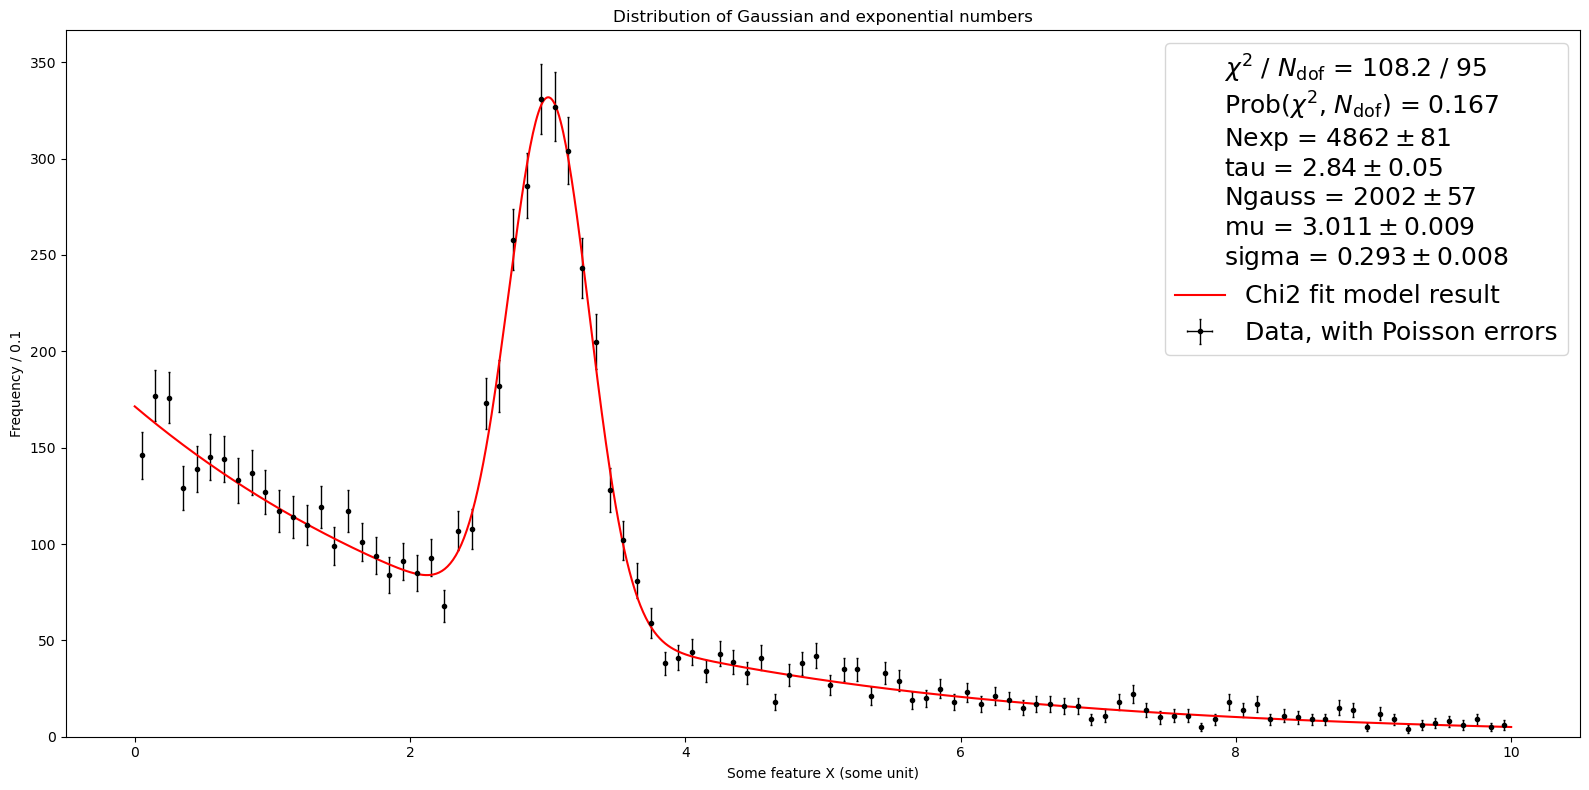

In [43]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig, ax = plt.subplots(figsize=(16, 8))  # figsize is in inches
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

# Set the figure texts; xlabel, ylabel and title.
ax.set(xlabel="Some feature X (some unit)", # the label of the y axis
       ylabel="Frequency / 0.1",  # the label of the y axis
       title="Distribution of Gaussian and exponential numbers", # the title of the plot
       ylim=[0.0,None]) # Setting the miminum to zero

# Adding fit function to plot:
x_axis = np.linspace(xmin, xmax, 1000)
ax.plot(x_axis, fit_pdf(x_axis, *mfit.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit.fval                     # ChiSquare value
Ndof = len(x[y > 0]) - mfit.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit.parameters, mfit.values[:], mfit.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig.tight_layout()

# Unbinned Likelihood fit:

For the *unbinned likelihood fit*, the input is again the x-values themselves, and bounds are possible, but no binning is suggested, as this is... well... unbinned.

In [44]:
ullhfit = cost.ExtendedUnbinnedNLL(x_all, fit_pdf_llhfit)
minuit_ullh = Minuit(ullhfit, Nexp=Nbkg, tau=2.9, Ngauss=Npeak, mu=3.1, sigma=0.3)
#minuit_ullh.limits["Nexp", "Ngauss"] = (0,1)
minuit_ullh.migrad()           # Perform the actual fit

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -8.34e+04                  │              Nfcn = 98               │
│ EDM = 9.75e-05 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Nexp   │  5.01e3   │  0.08e3   │            │            │         │         │       │
│ 1 │ tau    │   2.94    │   0.04    │            │            │         │         │       │
│ 2 │ Ngauss │  1.99e3   │  0.06e3   │            │            │         │         │       │
│ 3 │ mu     │   3.010   │   0.009   │            │            │         │         │       │
│ 4 │ sigma  │   0.294   │   0.008   │            │            │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────┬────────────────────────────────────────────────────────┐
│        │       Nexp        tau     Ngauss         mu      sigma │
├────────┼────────────────────────────────────────────────────────┤
│   Nexp │   6.25e+03     0.0047     -1.2e3   31.50e-3 -143.03e-3 │
│    tau │     0.0047    0.00173    -0.0047   -0.02e-3          0 │
│ Ngauss │     -1.2e3    -0.0047   3.23e+03  -31.55e-3  143.25e-3 │
│     mu │   31.50e-3   -0.02e-3  -31.55e-3   8.37e-05   -0.01e-3 │
│  sigma │ -143.03e-3          0  143.25e-3   -0.01e-3   6.52e-05 │
└────────┴────────────────────────────────────────────────────────┘

[1694.6662116  1637.22549447 1581.73173065 1528.11892814 1476.32333176
 1426.2833473  1377.93946829 1331.23420523 1286.11201722 1242.51924594
 1200.40405196 1159.71635404 1120.40777717 1082.43164606 1045.74323473
 1010.3013186   976.07553927  943.07628462  911.45951759  881.84295523
  856.1150568   839.14951959  841.67306804  883.58756651  995.09466167
 1211.04408038 1554.83046543 2014.60340969 2524.71799348 2970.53503732
 3225.23304066 3204.81802583 2909.26571576 2422.52150501 1871.35822445
 1370.36623934  985.14145255  727.48499355  573.95262246  489.64463684
  444.30897662  417.99286618  399.91811148  385.15892607  371.77407999
  359.09234125  346.90342406  335.14174518  323.7815295   312.80686322
  302.20426109  291.96104508  282.06502428  272.50442928  263.2678907
  254.34442463  245.72341948  237.39462332  229.34813174  221.57437602
  214.06411177  206.80840796  199.79863625  193.02646078  186.48382822
  180.16295822  174.05633412  168.15669407  162.45702234  156.95054101
  151.6

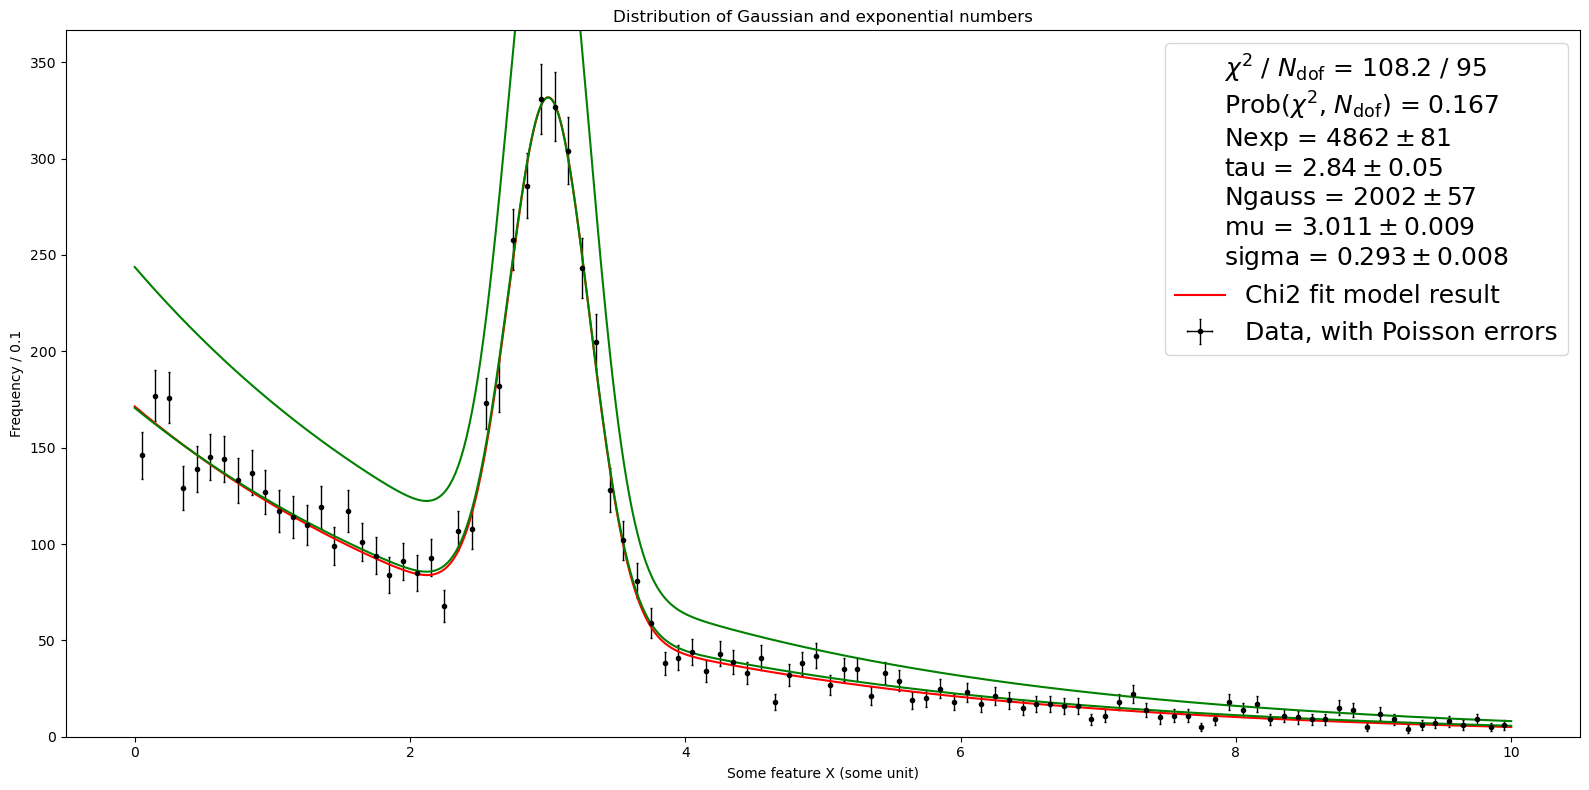

In [46]:
if (not minuit_ullh.fmin.is_valid) :
    print("  WARNING: The Unbinned Likelihood fit DID NOT converge!!! ")

#print(x_axis)
print(fit_pdf_llhfit(x,Nexp=Nbkg, tau=2.9, Ngauss=Npeak, mu=3.1, sigma=0.3)[1])


# Notice how both results are plotted with the "usual" PDF, as the fit parameters should be correct/similar. 
ax.plot(x_axis, fit_pdf(x_axis, *minuit_ullh.values[:]), '-g', label='Unbinned LLH fit model result') 
fig

# Binned Likelihood fit:

The *binned likelihood fit* is left as an exercise, possibly drawing inspiration from the [iMinuit2 Read-the-Docs entry on BinnedLLH](https://scikit-hep.org/iminuit/reference.html#iminuit.cost.BinnedNLL).

In [47]:
bllhfit = cost.BinnedNLL(y,bin_edges, fit_pdf_llhfit)
minuit_bllh = Minuit(bllhfit, Nexp=Nbkg, tau=2.9, Ngauss=Npeak, mu=3.1, sigma=0.3)
#minuit_ullh.limits["Nexp", "Ngauss"] = (0,1)
minuit_bllh.migrad()           # Perform the actual fit

/home/peter/anaconda3/lib/python3.13/site-packages/iminuit/cost.py:2551: PerformanceWarning: model should return numpy array, but returns <class 'tuple'>
  warnings.warn(msg, PerformanceWarning)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

# Questions:

This exercise is meant for you to see to what extend the three fitting methods give the same results when varying the input parameters, especially when the number of signal and background events is low, and also when the binning is (too) coarse.

1) Start by drawing all three fits on top of the data. Do they (by eye) give the same result, and does the fit generally look "good"? How do you judge that? Also, compare the fitted values of the three fits, and see if they agree within uncertainties?

2) Now repeat question 1) for lower statistics cases, for example Ngauss = 20 and Nexp = 50. See to what extend the different methods yields reasonable results (i.e. in accordance with the input values). You will encounter problems to be mended by yourself, such as empty bins (should not be passed to the ChiSquare dividing by "observed events", but is fine for the LLH fits) and poor initial values.
Possibly also alter the number of bins to 50 or 25 - is that a good choice? Why/why not?

3) Try to write a binned LLH fit, and test to what extend this "suffers" from low statistics.


### Advanced question:

4) Knowing the PDFs used for producing the data, try to see, if you can produce a goodness-of-fit measure for the unbinned likelihood fit by repeating this type of fit many times on (re-)simulated data. The "recipe" is:
  - Fit the data with an unbinned LLH fit.
  - Simulate new data N=1000(?) times with the same PDF, and using the parameters of the original fit.
  - Fit each of these new datasets, and save the LLH value (well, -2*ln(LLH)).
  - Plot the 1000 LLH values, which should have a Gaussian distribution.
  - Compare your original LLH value with this distribution, and ask what fraction has a worse (i.e. higher) LLH value.
  - This fraction is your p-value: **The probability of getting a worse result, given that the PDF is correct**.

5) Improve on the printing of results on the plots to better align and have a choice of decimals :-)

---

# Learning points:

The exercise is meant as an illustration of the three main fitting paradigms:
1. ChiSquare (binned)
2. Likelihood (binned)
3. Likelihood (unbinned)

While the ChiSquare is almost always recommendable to start out with, low statistics makes it non-optimal. If possible, use an unbinned likelihood, and if the data is already binned, use a binned likelihood.